# Final Project — Python for Data Analytics

CRM data analysis for an online coding school: cleaning, EDA, marketing, sales, products and unit economics.

## 1. Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Loading the data
If you run this in Google Colab, first upload the 4 xlsx files to the Files panel on the left.

In [2]:
deals = pd.read_excel("Deals (Done).xlsx")
spend = pd.read_excel("Spend (Done).xlsx")
contacts = pd.read_excel("Contacts (Done).xlsx")
calls = pd.read_excel("Calls (Done).xlsx")

for name, df in {"deals": deals, "spend": spend, "contacts": contacts, "calls": calls}.items():
    print(name, df.shape)
    display(df.head(3))

deals (21595, 23)


,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Page,Campaign,SLA,Content,Term,Source,Payment Type,Product,Education Type,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch
0,"5,805,028,000,056,864,768.00",Ben Hall,NaN,NaN,New Lead,NaN,/eng/test,03.07.23women,NaN,v16,women,Facebook Ads,NaN,NaN,NaN,21.06.2024 15:30,NaN,NaN,NaN,NaN,"5,805,028,000,056,849,408.00",NaN,NaN
1,"5,805,028,000,056,859,648.00",Ulysses Adams,NaN,NaN,New Lead,NaN,/at-eng,NaN,NaN,NaN,NaN,Organic,NaN,Web Developer,Morning,21.06.2024 15:23,6.00,NaN,0,2000,"5,805,028,000,056,834,048.00",NaN,NaN
2,"5,805,028,000,056,832,000.00",Ulysses Adams,21.06.2024,D - Non Target,Lost,Non target,/at-eng,engwien_AT,00:26:43,b1-at,21_06_2024,Telegram posts,NaN,NaN,NaN,21.06.2024 14:45,NaN,NaN,NaN,NaN,"5,805,028,000,056,854,528.00",NaN,NaN


spend (20779, 8)


,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad
0,2023-07-03,Google Ads,gen_analyst_DE,6,0.00,0,NaN,NaN
1,2023-07-03,Google Ads,performancemax_eng_DE,4,0.01,1,NaN,NaN
2,2023-07-03,Facebook Ads,NaN,0,0.00,0,NaN,NaN


contacts (18548, 4)


,Id,Contact Owner Name,Created Time,Modified Time
0,5805028000000645014,Rachel White,27.06.2023 11:28,22.12.2023 13:34
1,5805028000000872003,Charlie Davis,03.07.2023 11:31,21.05.2024 10:23
2,5805028000000889001,Bob Brown,02.07.2023 22:37,21.12.2023 13:17


calls (95874, 11)


,Id,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Dialled Number,Outgoing Call Status,Scheduled in CRM,Tag
0,5805028000000805001,30.06.2023 08:43,John Doe,NaN,Inbound,171.00,Received,NaN,NaN,NaN,NaN
1,5805028000000768006,30.06.2023 08:46,John Doe,NaN,Outbound,28.00,Attended Dialled,NaN,Completed,0.00,NaN
2,5805028000000764027,30.06.2023 08:59,John Doe,NaN,Outbound,24.00,Attended Dialled,NaN,Completed,0.00,NaN


## 3. Initial data inspection

In [3]:
def data_overview(df, name):
    print(f"--- {name} ---")
    print("Rows, columns:", df.shape)
    print("Duplicates:", df.duplicated().sum())
    display(pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_share": df.isna().mean()
    }).sort_values("missing_share", ascending=False))

data_overview(deals, "Deals")
data_overview(spend, "Spend")
data_overview(contacts, "Contacts")
data_overview(calls, "Calls")

--- Deals ---
Rows, columns: (21595, 23)
Duplicates: 3


,missing_count,missing_share
Payment Type,21099,0.98
Months of study,20755,0.96
Level of Deutsch,20344,0.94
City,19084,0.88
Education Type,18295,0.85
Course duration,18008,0.83
Product,18003,0.83
Initial Amount Paid,17430,0.81
Offer Total Amount,17410,0.81
Term,9141,0.42


--- Spend ---
Rows, columns: (20779, 8)
Duplicates: 917


,missing_count,missing_share
AdGroup,6828,0.33
Ad,6828,0.33
Campaign,5994,0.29
Date,0,0.00
Impressions,0,0.00
Source,0,0.00
Clicks,0,0.00
Spend,0,0.00


--- Contacts ---
Rows, columns: (18548, 4)
Duplicates: 0


,missing_count,missing_share
Id,0,0.00
Contact Owner Name,0,0.00
Created Time,0,0.00
Modified Time,0,0.00


--- Calls ---
Rows, columns: (95874, 11)


Duplicates: 0


,missing_count,missing_share
Tag,95874,1.00
Dialled Number,95874,1.00
Scheduled in CRM,8999,0.09
Outgoing Call Status,8999,0.09
CONTACTID,3933,0.04
Call Duration (in seconds),83,0.00
Id,0,0.00
Call Owner Name,0,0.00
Call Start Time,0,0.00
Call Status,0,0.00


## 4. Cleaning Deals

In [4]:
deals_clean = deals.copy()

# Drop rows without Id — technically empty rows
before = len(deals_clean)
deals_clean = deals_clean[deals_clean["Id"].notna()].copy()
print("Removed empty Id rows:", before - len(deals_clean))

# Full-row duplicates (all columns match)
before = len(deals_clean)
deals_clean = deals_clean.drop_duplicates()
print("Removed full duplicates:", before - len(deals_clean))

# Content duplicates IGNORING Id: the same deal may have been exported
# under different Ids. If all other fields match, it is a duplicate.
orig_cols = [c for c in deals.columns if c != "Id"]
before = len(deals_clean)
deals_clean = deals_clean.drop_duplicates(subset=orig_cols, keep="first")
print("Removed duplicates ignoring Id:", before - len(deals_clean))

# Dates: file format is day.month.year hours:minutes
deals_clean["created_date"] = pd.to_datetime(deals_clean["Created Time"], format="%d.%m.%Y %H:%M", errors="coerce")
deals_clean["closing_date_clean"] = pd.to_datetime(deals_clean["Closing Date"], format="%d.%m.%Y", errors="coerce")

# Successful-deal flag: Payment Done means a payment was made
deals_clean["is_success"] = (deals_clean["Stage"] == "Payment Done").astype(int)

# Deal closing time
deals_clean["close_days"] = (deals_clean["closing_date_clean"] - deals_clean["created_date"]).dt.days

deals_clean["date_error"] = np.where(deals_clean["close_days"] < 0, "closing_before_created", "")

# Flag for duplicate-reason losses
deals_clean["is_duplicate_lost"] = (deals_clean["Lost Reason"] == "Duplicate").astype(int)

# Revenue: count Initial Amount Paid only for successful deals
# Replace errors/missing amounts with 0
deals_clean["Initial Amount Paid"] = pd.to_numeric(deals_clean["Initial Amount Paid"], errors="coerce")
deals_clean["Offer Total Amount"] = pd.to_numeric(deals_clean["Offer Total Amount"], errors="coerce")
deals_clean["amount_for_revenue"] = np.where(
    deals_clean["is_success"].eq(1) & deals_clean["Initial Amount Paid"].notna(),
    deals_clean["Initial Amount Paid"],
    0
)

# SLA is stored as a reaction time (datetime.time, e.g. 0:26:43),
# not as a number of seconds. We convert it correctly to seconds and hours.
def _sla_to_seconds(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, dt.time):
        return v.hour * 3600 + v.minute * 60 + v.second
    try:
        return float(v)
    except (TypeError, ValueError):
        return np.nan

deals_clean["sla_seconds"] = deals_clean["SLA"].apply(_sla_to_seconds)
deals_clean["sla_hours"] = deals_clean["sla_seconds"] / 3600

deals_clean["month_created"] = deals_clean["created_date"].dt.to_period("M").astype(str)

# --- Diagnostics of the cleaning decisions ---
# Duplicate leads per CRM (Lost Reason = "Duplicate") are NOT removed,
# we only flag them with is_duplicate_lost: these are real repeat
# inquiries; removing them would distort the funnel. We removed only full
# row duplicates and rows without Id.
print("Lost-reason='Duplicate' leads (kept, flagged):",
      int(deals_clean["is_duplicate_lost"].sum()))
# In ~23% of rows the closing date precedes the creation date (CRM input error).
# We flag these (date_error) and exclude them from the closing-time analysis.
print("Deals with negative close_days (closing before creation):",
      int((deals_clean["close_days"] < 0).sum()))
print("SLA: non-null values after conversion:",
      int(deals_clean["sla_hours"].notna().sum()))

display(deals_clean.head())
print(deals_clean.shape)

Removed empty Id rows: 2
Removed full duplicates: 3
Removed duplicates ignoring Id: 9


Lost-reason='Duplicate' leads (kept, flagged): 1765
Deals with negative close_days (closing before creation): 3307
SLA: non-null values after conversion: 13672


,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Page,Campaign,SLA,Content,Term,Source,Payment Type,Product,Education Type,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch,created_date,closing_date_clean,is_success,close_days,date_error,is_duplicate_lost,amount_for_revenue,sla_seconds,sla_hours,month_created
0,"5,805,028,000,056,864,768.00",Ben Hall,NaN,NaN,New Lead,NaN,/eng/test,03.07.23women,NaN,v16,women,Facebook Ads,NaN,NaN,NaN,21.06.2024 15:30,NaN,NaN,NaN,NaN,"5,805,028,000,056,849,408.00",NaN,NaN,2024-06-21 15:30:00,NaT,0,NaN,,0,0.00,NaN,NaN,2024-06
1,"5,805,028,000,056,859,648.00",Ulysses Adams,NaN,NaN,New Lead,NaN,/at-eng,NaN,NaN,NaN,NaN,Organic,NaN,Web Developer,Morning,21.06.2024 15:23,6.00,NaN,0.00,"2,000.00","5,805,028,000,056,834,048.00",NaN,NaN,2024-06-21 15:23:00,NaT,0,NaN,,0,0.00,NaN,NaN,2024-06
2,"5,805,028,000,056,832,000.00",Ulysses Adams,21.06.2024,D - Non Target,Lost,Non target,/at-eng,engwien_AT,00:26:43,b1-at,21_06_2024,Telegram posts,NaN,NaN,NaN,21.06.2024 14:45,NaN,NaN,NaN,NaN,"5,805,028,000,056,854,528.00",NaN,NaN,2024-06-21 14:45:00,2024-06-21,0,-1.00,closing_before_created,0,0.00,"1,603.00",0.45,2024-06
3,"5,805,028,000,056,823,808.00",Eva Kent,21.06.2024,E - Non Qualified,Lost,Invalid number,/eng,04.07.23recentlymoved_DE,01:00:04,bloggersvideo14com,recentlymoved,Facebook Ads,NaN,NaN,NaN,21.06.2024 13:32,NaN,NaN,NaN,NaN,"5,805,028,000,056,888,320.00",NaN,NaN,2024-06-21 13:32:00,2024-06-21,0,-1.00,closing_before_created,0,0.00,"3,604.00",1.00,2024-06
4,"5,805,028,000,056,872,960.00",Ben Hall,21.06.2024,D - Non Target,Lost,Non target,/eng,discovery_DE,00:53:12,website,NaN,Google Ads,NaN,NaN,NaN,21.06.2024 13:21,NaN,NaN,NaN,NaN,"5,805,028,000,056,876,032.00",NaN,NaN,2024-06-21 13:21:00,2024-06-21,0,-1.00,closing_before_created,0,0.00,"3,192.00",0.89,2024-06


(21581, 33)


**Cleaning decisions**

- Removed rows without `Id`, full-row duplicates, and content duplicates **ignoring `Id`** (the same deal could appear in the export under different Ids).
- All four tables were cleaned: Deals, Spend, Calls and Contacts (in Calls the fully empty columns Dialled Number and Tag and 3,260 duplicates were removed; see sections 5 and 5b).
- Leads with `Lost Reason = "Duplicate"` (repeat inquiries) are **kept** and flagged with `is_duplicate_lost` rather than removed: these are real funnel events, and removing them would understate the number of leads and distort conversion.
- Missing values in monetary fields are treated as `0`; for revenue we use `Initial Amount Paid` only for successful deals (the amount actually received — a conservative estimate; the full contract value `Offer Total Amount` is higher).
- The `SLA` field is stored as a reaction time (`datetime.time`) and converted to seconds and hours.
- In ~23% of rows the closing date precedes the creation date — a CRM input error; such rows are flagged with `date_error` and excluded from the closing-time analysis.

## 5. Cleaning Spend

In [5]:
spend_clean = spend.copy()

spend_clean = spend_clean.drop_duplicates()
spend_clean["Date"] = pd.to_datetime(spend_clean["Date"], errors="coerce")
spend_clean["Spend"] = pd.to_numeric(spend_clean["Spend"], errors="coerce").fillna(0)
spend_clean["Clicks"] = pd.to_numeric(spend_clean["Clicks"], errors="coerce").fillna(0)
spend_clean["Impressions"] = pd.to_numeric(spend_clean["Impressions"], errors="coerce").fillna(0)

# For unit economics we keep spend, but do not drop zero rows from the full dataset
spend_positive = spend_clean[spend_clean["Spend"] > 0].copy()

print("Spend rows:", spend_clean.shape)
print("Positive spend rows:", spend_positive.shape)
display(spend_positive.head())

Spend rows: (19862, 8)
Positive spend rows: (14268, 8)


,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad
1,2023-07-03,Google Ads,performancemax_eng_DE,4,0.01,1,NaN,NaN
5,2023-07-03,Facebook Ads,03.07.23women,187,3.30,6,women,b3
6,2023-07-03,Facebook Ads,03.07.23women,4,0.02,1,women,b1
9,2023-07-03,Facebook Ads,02.07.23wide_DE,61,0.58,0,wide,b4
10,2023-07-03,Facebook Ads,02.07.23wide_DE,21,0.24,1,wide,b1


## 6. Key KPIs

## 5b. Cleaning Calls and Contacts

In addition to Deals and Spend, we clean the two remaining tables. For each: drop fully empty columns, full duplicates and duplicates ignoring `Id`, convert dates to datetime and record missing values.

In [6]:
# --- Calls ---
calls_clean = calls.copy()

# Fully empty columns are uninformative — drop them
empty_cols = [c for c in calls_clean.columns if calls_clean[c].isna().all()]
calls_clean = calls_clean.drop(columns=empty_cols)
print("Calls: dropped empty columns:", empty_cols)

# Full duplicates + duplicates ignoring Id
before = len(calls_clean)
calls_clean = calls_clean.drop_duplicates()
id_cols = [c for c in calls_clean.columns if c != "Id"]
calls_clean = calls_clean.drop_duplicates(subset=id_cols, keep="first")
print("Calls: duplicates removed (incl. ignoring Id):", before - len(calls_clean))

# Data types
calls_clean["Call Start Time"] = pd.to_datetime(
    calls_clean["Call Start Time"], format="%d.%m.%Y %H:%M", errors="coerce")
calls_clean["Call Duration (in seconds)"] = pd.to_numeric(
    calls_clean["Call Duration (in seconds)"], errors="coerce")

print("Calls: missing values per column:")
print(calls_clean.isna().sum()[calls_clean.isna().sum() > 0])
print("Calls final:", calls_clean.shape)

# --- Contacts ---
contacts_clean = contacts.copy()
before = len(contacts_clean)
contacts_clean = contacts_clean.drop_duplicates()
id_cols_c = [c for c in contacts_clean.columns if c != "Id"]
contacts_clean = contacts_clean.drop_duplicates(subset=id_cols_c, keep="first")
print("Contacts: duplicates removed (incl. ignoring Id):", before - len(contacts_clean))

contacts_clean["Created Time"] = pd.to_datetime(
    contacts_clean["Created Time"], format="%d.%m.%Y %H:%M", errors="coerce")
contacts_clean["Modified Time"] = pd.to_datetime(
    contacts_clean["Modified Time"], format="%d.%m.%Y %H:%M", errors="coerce")
print("Contacts final:", contacts_clean.shape)
display(contacts_clean.head(3))

Calls: dropped empty columns: ['Dialled Number', 'Tag']


Calls: duplicates removed (incl. ignoring Id): 3260


Calls: missing values per column:
CONTACTID                     3802
Call Duration (in seconds)      79
Outgoing Call Status          8812
Scheduled in CRM              8812
dtype: int64
Calls final: (92614, 9)
Contacts: duplicates removed (incl. ignoring Id): 38
Contacts final: (18510, 4)


,Id,Contact Owner Name,Created Time,Modified Time
0,5805028000000645014,Rachel White,2023-06-27 11:28:00,2023-12-22 13:34:00
1,5805028000000872003,Charlie Davis,2023-07-03 11:31:00,2024-05-21 10:23:00
2,5805028000000889001,Bob Brown,2023-07-02 22:37:00,2023-12-21 13:17:00


In [7]:
total_leads = len(deals_clean)
success_deals = deals_clean["is_success"].sum()
conversion_rate = round(success_deals / total_leads * 100, 2)
revenue = deals_clean["amount_for_revenue"].sum()
avg_check = revenue / success_deals

kpi = pd.DataFrame({
    "Metric": ["Total Leads", "Successful Deals", "Conversion Rate", "Revenue", "Average Check"],
    "Value": [total_leads, success_deals, conversion_rate, revenue, avg_check]
})
display(kpi)

,Metric,Value
0,Total Leads,"21,581.00"
1,Successful Deals,858.00
2,Conversion Rate,3.98
3,Revenue,"943,651.00"
4,Average Check,"1,099.83"


## 6b. Descriptive statistics of numeric fields

Summary statistics (mean, median, **mode**, minimum, maximum, **range**, standard deviation) for the key numeric fields — as required by the assignment.

In [8]:
# Only truly continuous numeric fields.
# Course duration and Months of study are categorical (program options),
# so they are not part of the numeric statistics (see section 6c).
num_cols = [
    "Initial Amount Paid",
    "Offer Total Amount",
    "close_days",
    "sla_hours",
]
num_cols = [c for c in num_cols if c in deals_clean.columns]

def describe_full(df, cols):
    rows = []
    for c in cols:
        s = pd.to_numeric(df[c], errors="coerce").dropna()
        if s.empty:
            continue
        mode_vals = s.mode()
        rows.append({
            "field": c,
            "count": int(s.count()),
            "mean": s.mean(),
            "median": s.median(),
            "mode": mode_vals.iloc[0] if not mode_vals.empty else np.nan,
            "min": s.min(),
            "max": s.max(),
            "range": s.max() - s.min(),
            "std": s.std(),
        })
    return pd.DataFrame(rows)

num_summary = describe_full(deals_clean, num_cols)
display(num_summary)

,field,count,mean,median,mode,min,max,range,std
0,Initial Amount Paid,4146,940.93,"1,000.00","1,000.00",0.00,"11,500.00","11,500.00","1,416.32"
1,Offer Total Amount,4161,"7,153.16","11,000.00","11,000.00",0.00,"11,500.00","11,500.00","4,635.63"
2,close_days,14638,13.89,2.00,-1.00,-358.00,334.00,692.00,31.80
3,sla_hours,13672,6.96,3.98,0.17,0.00,23.98,23.98,6.81


## 6c. Descriptive statistics of categorical fields

Analysis of categorical variables. `Course duration` and `Months of study` are included here — by their meaning these are categories (program options), not continuous quantities. For each field we compute: the number of non-null values, the share of missing values, the number of unique categories, the mode (the most frequent category) and its share. A detailed distribution of the key fields follows.

In [9]:
cat_cols = [
    "Quality", "Stage", "Source", "Product", "Education Type",
    "Payment Type", "Campaign", "City", "Level of Deutsch", "Lost Reason",
    "Course duration", "Months of study",
]
cat_cols = [c for c in cat_cols if c in deals_clean.columns]

def describe_categorical(df, cols):
    rows = []
    for c in cols:
        s = df[c]
        nn = int(s.notna().sum())
        vc = s.value_counts(dropna=True)
        top = vc.index[0] if len(vc) else np.nan
        topn = int(vc.iloc[0]) if len(vc) else 0
        rows.append({
            "field": c,
            "non_null": nn,
            "missing_%": round(s.isna().mean() * 100, 1),
            "n_unique": int(s.nunique(dropna=True)),
            "mode (top)": top,
            "top_count": topn,
            "top_share_%": round(topn / nn * 100, 1) if nn else np.nan,
        })
    return pd.DataFrame(rows)

cat_summary = describe_categorical(deals_clean, cat_cols)
display(cat_summary)

# Detailed distribution of the key categorical fields
for c in ["Quality", "Stage", "Source", "Product", "Course duration", "Months of study"]:
    vc = deals_clean[c].value_counts(dropna=False)
    out = pd.DataFrame({"count": vc, "share_%": (vc / len(deals_clean) * 100).round(1)})
    print(f"\n--- {c} ---")
    display(out.head(10))

,field,non_null,missing_%,n_unique,mode (top),top_count,top_share_%
0,Quality,19333,10.40,6,E - Non Qualified,7627,39.50
1,Stage,21581,0.00,13,Lost,15736,72.90
2,Source,21581,0.00,13,Facebook Ads,4849,22.50
3,Product,3592,83.40,5,Digital Marketing,1990,55.40
4,Education Type,3299,84.70,2,Morning,2895,87.80
5,Payment Type,496,97.70,3,Recurring Payments,350,70.60
6,Campaign,16062,25.60,154,performancemax_digitalmarkt_ru_DE,2650,16.50
7,City,2511,88.40,876,-,348,13.90
8,Level of Deutsch,1251,94.20,215,B1,219,17.50
9,Lost Reason,16117,25.30,21,Doesn't Answer,4134,25.60



--- Quality ---


,count,share_%
Quality,,
E - Non Qualified,7627,35.30
D - Non Target,6248,29.00
C - Low,3459,16.00
NaN,2248,10.40
B - Medium,1564,7.20
A - High,432,2.00
F,3,0.00



--- Stage ---


,count,share_%
Stage,,
Lost,15736,72.90
Call Delayed,2248,10.40
Registered on Webinar,2068,9.60
Payment Done,858,4.00
Waiting For Payment,325,1.50
Qualificated,128,0.60
Registered on Offline Day,100,0.50
Need to Call - Sales,33,0.20
Need To Call,31,0.10


...

,count,share_%
Product,,
NaN,17989,83.40
Digital Marketing,1990,9.20
UX/UI Design,1022,4.70
Web Developer,575,2.70
Find yourself in IT,4,0.00
Data Analytics,1,0.00



--- Course duration ---


,count,share_%
Course duration,,
NaN,17994,83.40
11.00,3012,14.00
6.00,575,2.70



--- Months of study ---


,count,share_%
Months of study,,
NaN,20741,96.10
6.00,107,0.50
2.00,104,0.50
3.00,94,0.40
4.00,93,0.40
8.00,83,0.40
7.00,79,0.40
1.00,67,0.30
5.00,64,0.30


## 7. Traffic source analysis

In [10]:
source_analysis = deals_clean.groupby("Source", dropna=False).agg(
    leads=("Id", "count"),
    success_deals=("is_success", "sum"),
    revenue=("amount_for_revenue", "sum")
).reset_index()

source_analysis["cr"] = source_analysis["success_deals"] / source_analysis["leads"]
source_analysis["cr_pct"] = round(source_analysis["cr"] * 100, 2)
source_analysis = source_analysis.sort_values("cr", ascending=False)

display(
    source_analysis[
        ["Source","leads","success_deals","revenue","cr_pct"]
    ]
)

,Source,leads,success_deals,revenue,cr_pct
11,Webinar,378,26,"55,150.00",6.88
5,Organic,2587,147,"179,951.00",5.68
7,SMM,1730,91,"96,250.00",5.26
2,Facebook Ads,4849,202,"222,150.00",4.17
3,Google Ads,4223,173,"167,850.00",4.10
8,Telegram posts,1000,40,"41,950.00",4.00
0,Bloggers,1089,39,"33,100.00",3.58
12,Youtube Ads,1657,53,"59,450.00",3.20
10,Tiktok Ads,2051,56,"66,650.00",2.73
6,Partnership,201,4,"3,350.00",1.99


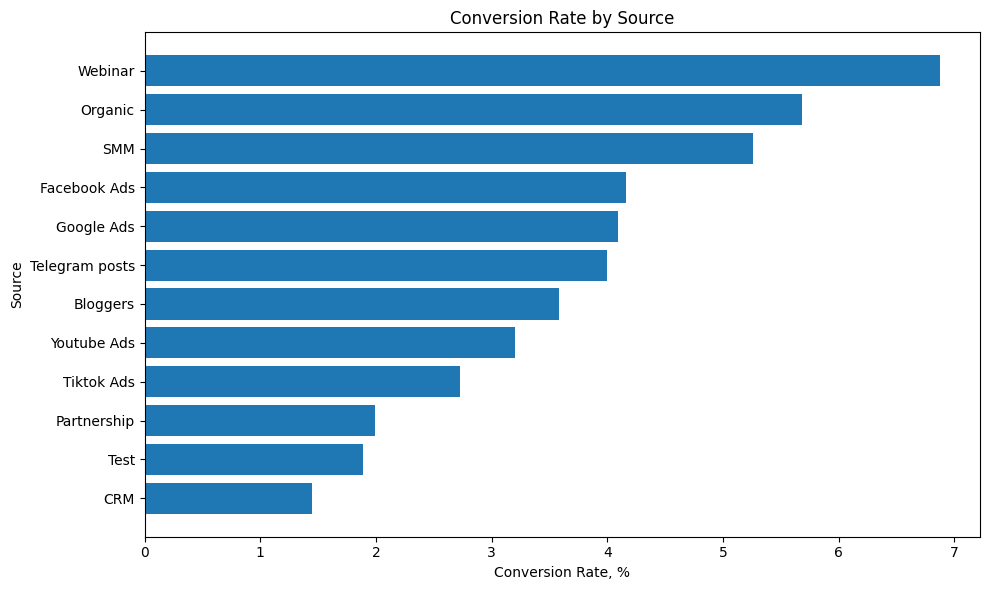

In [11]:
plot_data = source_analysis.dropna(subset=["Source"]).copy()
plot_data = plot_data[plot_data["leads"] > 10].sort_values("cr")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["Source"], plot_data["cr"] * 100)
plt.title("Conversion Rate by Source")
plt.xlabel("Conversion Rate, %")
plt.ylabel("Source")
plt.tight_layout()
plt.show()

## 8. Campaign analysis

,Campaign,leads,success_deals,revenue,cr
118,performancemax_digitalmarkt_ru_DE,2650,112,"100,500.00",0.04
18,12.07.2023wide_DE,1575,48,"61,850.00",0.03
2,02.07.23wide_DE,975,52,"59,750.00",0.05
152,youtube_shorts_DE,1635,53,"59,450.00",0.03
8,07.07.23LAL_DE,542,28,"47,150.00",0.05
5,04.07.23recentlymoved_DE,750,31,"36,300.00",0.04
83,brand_search_eng_DE,168,15,"30,250.00",0.09
4,03.07.23women,612,31,"27,600.00",0.05
19,12.09.23interests_Uxui_DE,531,27,"25,600.00",0.05
60,Dis_DE,581,30,"24,200.00",0.05


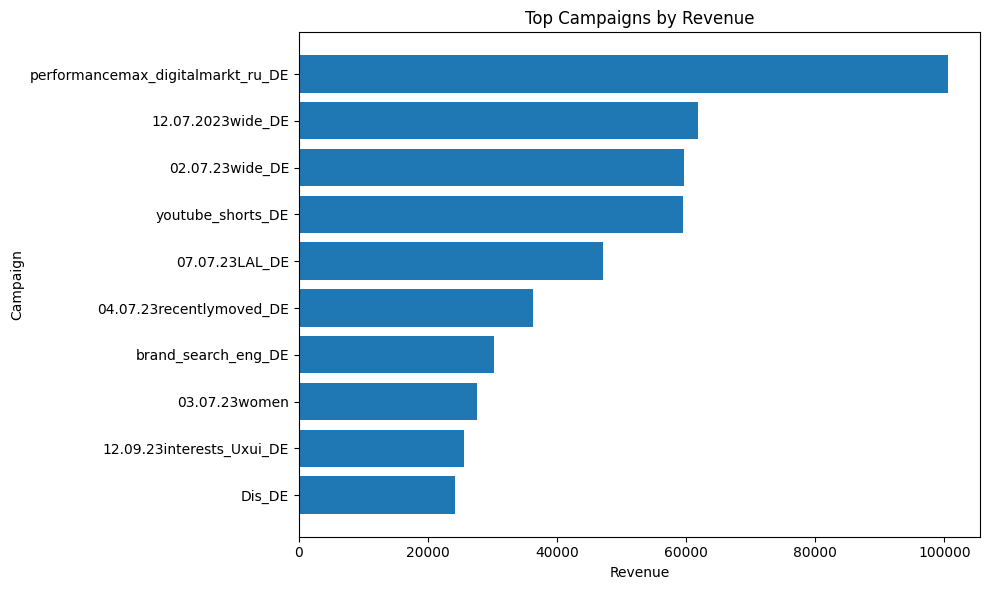

In [12]:
campaign_analysis = deals_clean.groupby("Campaign", dropna=False).agg(
    leads=("Id", "count"),
    success_deals=("is_success", "sum"),
    revenue=("amount_for_revenue", "sum")
).reset_index()

campaign_analysis["cr"] = (
    campaign_analysis["success_deals"] /
    campaign_analysis["leads"]
)

campaign_analysis = campaign_analysis[
    campaign_analysis["Campaign"].notna()
]

campaign_analysis = campaign_analysis[
    campaign_analysis["leads"] >= 30
]

display(
    campaign_analysis.sort_values(
        "revenue",
        ascending=False
    ).head(15)
)

plot_campaign = campaign_analysis.sort_values(
    "revenue"
).tail(10)

plt.figure(figsize=(10,6))
plt.barh(
    plot_campaign["Campaign"],
    plot_campaign["revenue"]
)

plt.title("Top Campaigns by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Campaign")

plt.tight_layout()
plt.show()

## 9. Sales analysis by deal owner

In [13]:
sales_analysis = deals_clean.groupby("Deal Owner Name", dropna=False).agg(
    leads=("Id", "count"),
    success_deals=("is_success", "sum"),
    revenue=("amount_for_revenue", "sum")
).reset_index()

sales_analysis["cr"] = sales_analysis["success_deals"] / sales_analysis["leads"]
sales_analysis["avg_revenue_per_success"] = np.where(
    sales_analysis["success_deals"] > 0,
    sales_analysis["revenue"] / sales_analysis["success_deals"],
    np.nan
)

display(sales_analysis.sort_values("revenue", ascending=False).head(15))
sales_analysis.sort_values("cr", ascending=False).head(10)

,Deal Owner Name,leads,success_deals,revenue,cr,avg_revenue_per_success
4,Cara Iverson,1056,27,"151,900.00",0.03,"5,625.93"
5,Charlie Davis,2961,148,"131,250.00",0.05,886.82
21,Ulysses Adams,2165,141,"127,100.00",0.07,901.42
17,Paula Underwood,1862,93,"98,150.00",0.05,"1,055.38"
12,Julia Nelson,2241,93,"78,051.00",0.04,839.26
18,Quincy Vincent,1884,65,"72,400.00",0.03,"1,113.85"
22,Victor Barnes,1232,44,"63,200.00",0.04,"1,436.36"
2,Ben Hall,1345,46,"55,200.00",0.03,"1,200.00"
16,Oliver Taylor,163,50,"46,750.00",0.31,935.00
15,Nina Scott,1282,46,"40,700.00",0.04,884.78


,Deal Owner Name,leads,success_deals,revenue,cr,avg_revenue_per_success
16,Oliver Taylor,163,50,"46,750.00",0.31,935.00
13,Kevin Parker,573,40,"23,950.00",0.07,598.75
21,Ulysses Adams,2165,141,"127,100.00",0.07,901.42
11,John Doe,19,1,0.00,0.05,0.00
5,Charlie Davis,2961,148,"131,250.00",0.05,886.82
17,Paula Underwood,1862,93,"98,150.00",0.05,"1,055.38"
12,Julia Nelson,2241,93,"78,051.00",0.04,839.26
7,Eva Kent,459,18,"16,600.00",0.04,922.22
15,Nina Scott,1282,46,"40,700.00",0.04,884.78
22,Victor Barnes,1232,44,"63,200.00",0.04,"1,436.36"


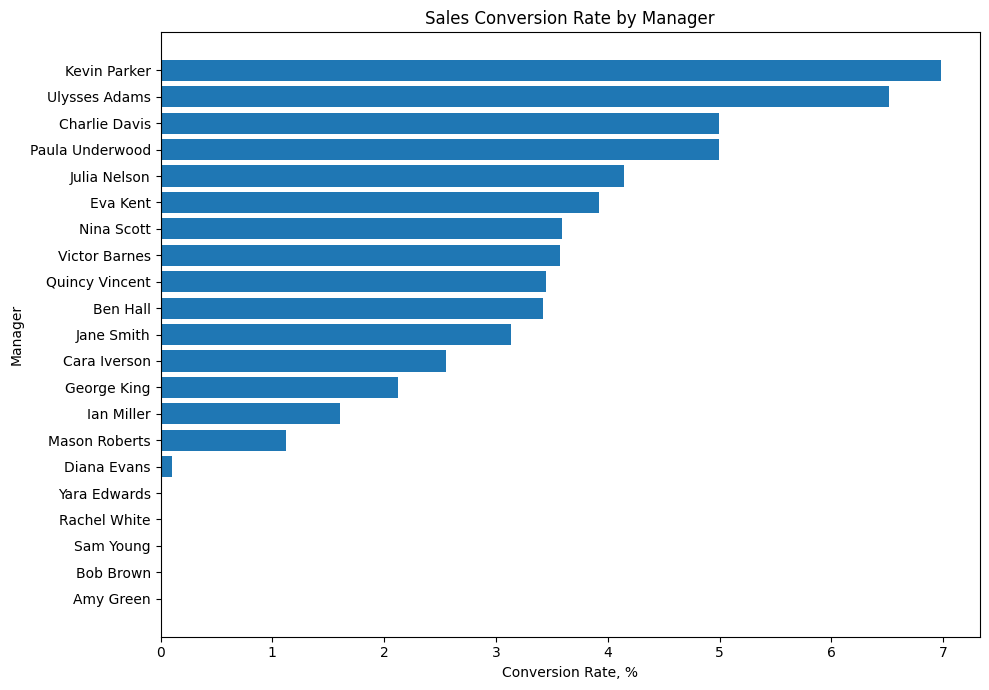

In [14]:
# For the chart we exclude deal owners with very small samples and clear outliers for readability
plot_sales = sales_analysis[(sales_analysis["leads"] >= 50) & (sales_analysis["cr"] < 0.15)].copy()
plot_sales = plot_sales.sort_values("cr")

plt.figure(figsize=(10, 7))
plt.barh(plot_sales["Deal Owner Name"], plot_sales["cr"] * 100)
plt.title("Sales Conversion Rate by Manager")
plt.xlabel("Conversion Rate, %")
plt.ylabel("Manager")
plt.tight_layout()
plt.show()

## 10. Product analysis

In [15]:
product_analysis = deals_clean.groupby("Product", dropna=False).agg(
    leads=("Id", "count"),
    success_deals=("is_success", "sum"),
    revenue=("amount_for_revenue", "sum")
).reset_index()

product_analysis["cr"] = product_analysis["success_deals"] / product_analysis["leads"]
product_analysis["avg_revenue"] = np.where(
    product_analysis["success_deals"] > 0,
    product_analysis["revenue"] / product_analysis["success_deals"],
    np.nan
)

# Keep products with a sufficient number of leads for the output
product_analysis_clean = product_analysis[(product_analysis["Product"].notna()) & (product_analysis["leads"] > 50)].copy()
display(product_analysis_clean.sort_values("revenue", ascending=False))

,Product,leads,success_deals,revenue,cr,avg_revenue
1,Digital Marketing,1990,474,"539,100.00",0.24,"1,137.34"
3,UX/UI Design,1022,229,"261,100.00",0.22,"1,140.17"
4,Web Developer,575,137,"143,450.00",0.24,"1,047.08"


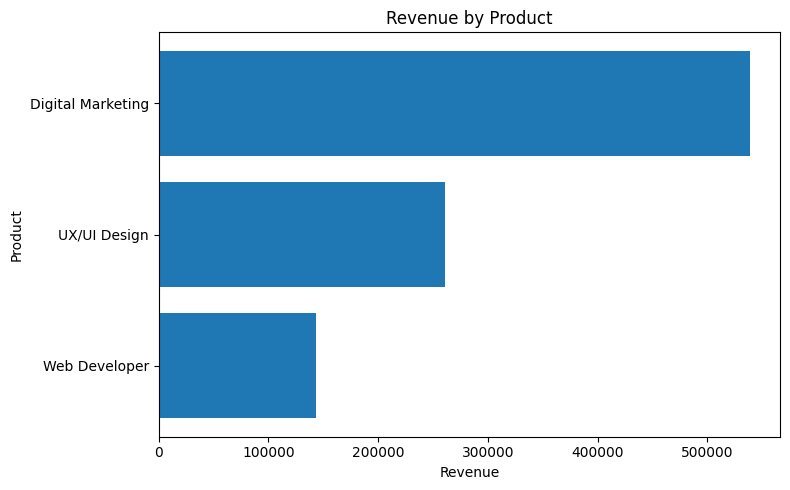

In [16]:
plot_product = product_analysis_clean.sort_values("revenue")
plt.figure(figsize=(8, 5))
plt.barh(plot_product["Product"], plot_product["revenue"])
plt.title("Revenue by Product")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 11. Payment Type analysis

,Payment Type,leads,success_deals,revenue,cr
3,NaN,21085,494,"628,000.00",0.02
0,One Payment,141,113,"204,451.00",0.80
1,Recurring Payments,350,250,"111,100.00",0.71
2,Reservation,5,1,100.00,0.20


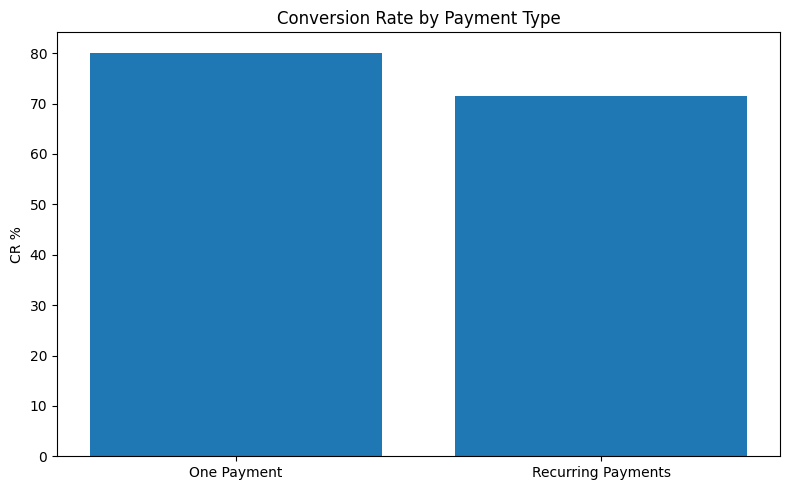

In [17]:
payment_analysis = deals_clean.groupby(
    "Payment Type",
    dropna=False
).agg(
    leads=("Id","count"),
    success_deals=("is_success","sum"),
    revenue=("amount_for_revenue","sum")
).reset_index()

payment_analysis["cr"] = (
    payment_analysis["success_deals"] /
    payment_analysis["leads"]
)

display(payment_analysis.sort_values(
    "revenue",
    ascending=False
))

plot_payment = payment_analysis[
    (payment_analysis["Payment Type"].notna()) &
    (payment_analysis["leads"] >= 20)
]

plt.figure(figsize=(8,5))

plt.bar(
    plot_payment["Payment Type"].astype(str),
    plot_payment["cr"] * 100
)

plt.title("Conversion Rate by Payment Type")
plt.ylabel("CR %")

plt.tight_layout()
plt.show()



## 12. Unit Economics

In [18]:
spend_by_source = spend_clean.groupby("Source", dropna=False).agg(
    spend=("Spend", "sum")
).reset_index()

unit_economics = source_analysis.merge(spend_by_source, on="Source", how="left")
unit_economics["spend"] = unit_economics["spend"].fillna(0)
unit_economics["cac"] = np.where(
    unit_economics["success_deals"] > 0,
    unit_economics["spend"] / unit_economics["success_deals"],
    np.nan
)
unit_economics["romi"] = np.where(
    unit_economics["spend"] > 0,
    (unit_economics["revenue"] - unit_economics["spend"]) / unit_economics["spend"],
    np.nan
)

display(unit_economics.sort_values("romi", ascending=False))

,Source,leads,success_deals,revenue,cr,cr_pct,spend,cac,romi
0,Webinar,378,26,"55,150.00",0.07,6.88,"2,874.04",110.54,18.19
2,SMM,1730,91,"96,250.00",0.05,5.26,"7,269.52",79.88,12.24
3,Facebook Ads,4849,202,"222,150.00",0.04,4.17,"33,754.72",167.10,5.58
5,Telegram posts,1000,40,"41,950.00",0.04,4.00,"6,860.36",171.51,5.11
8,Tiktok Ads,2051,56,"66,650.00",0.03,2.73,"11,985.67",214.03,4.56
7,Youtube Ads,1657,53,"59,450.00",0.03,3.20,"14,633.33",276.10,3.06
10,Test,159,3,"2,200.00",0.02,1.89,608.21,202.74,2.62
4,Google Ads,4223,173,"167,850.00",0.04,4.10,"57,798.60",334.10,1.90
6,Bloggers,1089,39,"33,100.00",0.04,3.58,"13,439.00",344.59,1.46
1,Organic,2587,147,"179,951.00",0.06,5.68,0.00,0.00,NaN


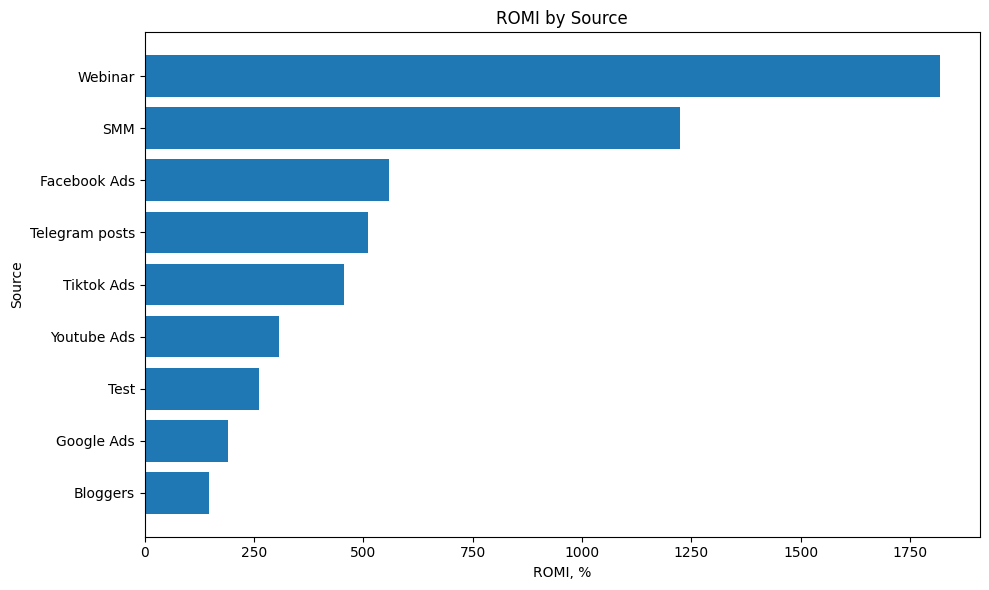

In [19]:
plot_romi = unit_economics.dropna(subset=["romi"]).copy()
plot_romi = plot_romi.sort_values("romi")

plt.figure(figsize=(10, 6))
plt.barh(plot_romi["Source"], plot_romi["romi"] * 100)
plt.title("ROMI by Source")
plt.xlabel("ROMI, %")
plt.ylabel("Source")
plt.tight_layout()
plt.show()

## 13. Time-series analysis

,month_created,leads,success_deals,revenue,cr
0,2023-07,650,10,"7,150.00",0.02
1,2023-08,1085,49,"32,200.00",0.05
2,2023-09,1079,53,"41,350.00",0.05
3,2023-10,1598,86,"72,100.00",0.05
4,2023-11,1945,104,"103,900.00",0.05


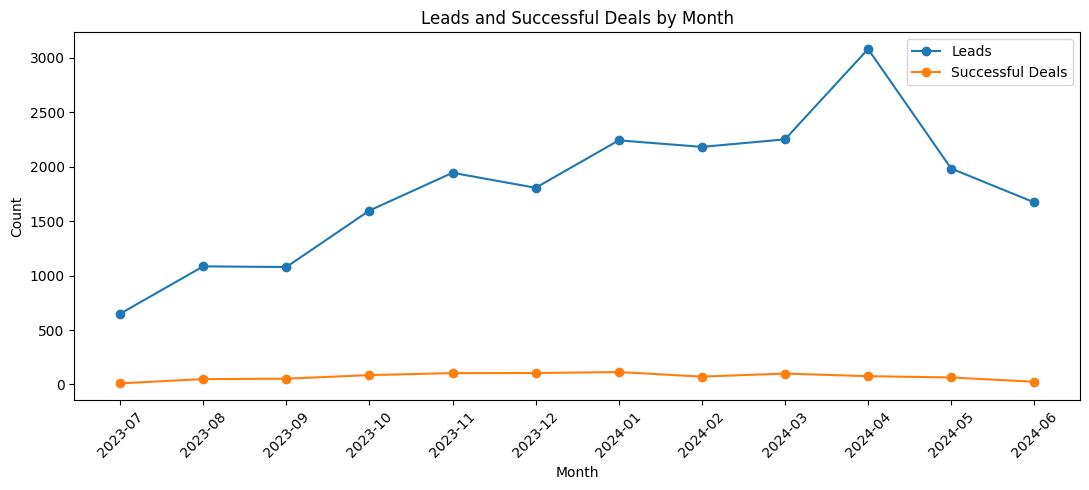

In [20]:
monthly = deals_clean.groupby("month_created").agg(
    leads=("Id", "count"),
    success_deals=("is_success", "sum"),
    revenue=("amount_for_revenue", "sum")
).reset_index()
monthly["cr"] = monthly["success_deals"] / monthly["leads"]

display(monthly.head())

plt.figure(figsize=(11, 5))
plt.plot(monthly["month_created"], monthly["leads"], marker="o", label="Leads")
plt.plot(monthly["month_created"], monthly["success_deals"], marker="o", label="Successful Deals")
plt.title("Leads and Successful Deals by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 14. Deal closing-time analysis

Closing time — all closed deals (incl. Lost):


count   11,331.00
mean        18.34
std         34.59
min          0.00
25%          1.00
50%          5.00
75%         17.00
max        334.00
Name: close_days, dtype: float64

Closing time — successful deals only (Payment Done):


count   495.00
mean     34.04
std      43.34
min       0.00
25%       6.50
50%      17.00
75%      43.00
max     304.00
Name: close_days, dtype: float64

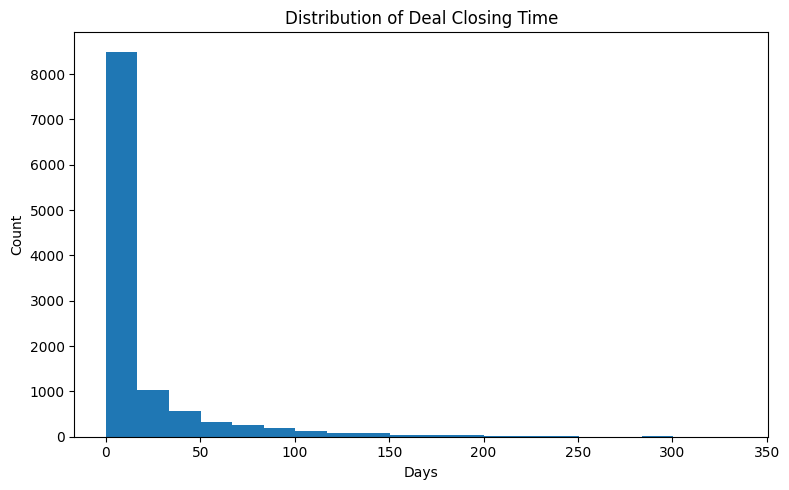

In [21]:
close_analysis = deals_clean[
    (deals_clean["close_days"].notna()) &
    (deals_clean["close_days"] >= 0)
]

# Closing time for WON deals only (Payment Done):
# this reflects the real sales cycle, not the closing of losses.
won_close = close_analysis[close_analysis["is_success"] == 1]

print("Closing time — all closed deals (incl. Lost):")
display(close_analysis["close_days"].describe())

print("Closing time — successful deals only (Payment Done):")
display(won_close["close_days"].describe())

plt.figure(figsize=(8,5))

plt.hist(
    close_analysis["close_days"],
    bins=20
)

plt.title("Distribution of Deal Closing Time")
plt.xlabel("Days")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 15. Lead quality analysis (Quality)

,Quality,leads,success_deals,revenue,cr
4,E - Non Qualified,7627,2,0.00,0.00
3,D - Non Target,6248,31,"28,001.00",0.00
2,C - Low,3459,355,"400,750.00",0.10
1,B - Medium,1564,327,"374,850.00",0.21
0,A - High,432,143,"140,050.00",0.33
5,F,3,0,0.00,0.00


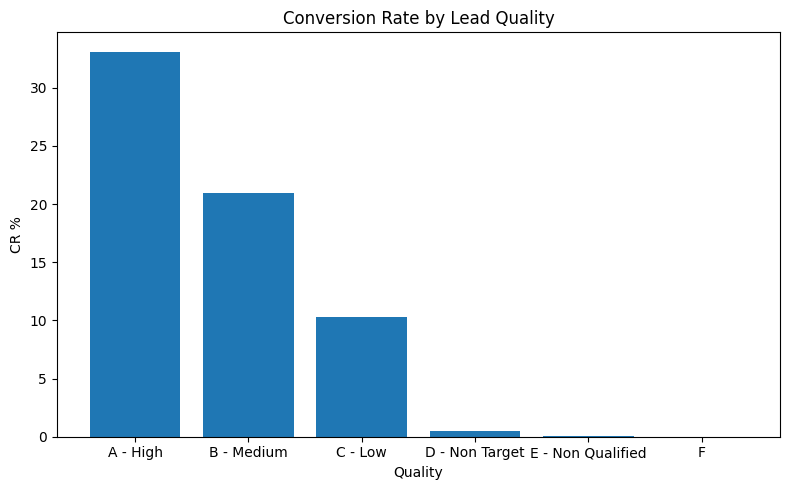

In [22]:
# 15. Lead quality analysis (Quality)

quality_analysis = deals_clean.groupby(
    "Quality",
    dropna=False
).agg(
    leads=("Id", "count"),
    success_deals=("is_success", "sum"),
    revenue=("amount_for_revenue", "sum")
).reset_index()

quality_analysis["cr"] = (
    quality_analysis["success_deals"] /
    quality_analysis["leads"]
)

quality_analysis = quality_analysis[
    quality_analysis["Quality"].notna()
]

display(
    quality_analysis.sort_values(
        "leads",
        ascending=False
    )
)

plt.figure(figsize=(8,5))

plt.bar(
    quality_analysis["Quality"].astype(str),
    quality_analysis["cr"] * 100
)

plt.title("Conversion Rate by Lead Quality")
plt.xlabel("Quality")
plt.ylabel("CR %")

plt.tight_layout()
plt.show()

## 16. Funnel stage analysis (Stage)

,Stage,deals,revenue
2,Lost,15736,0.00
0,Call Delayed,2248,0.00
10,Registered on Webinar,2068,0.00
7,Payment Done,858,"943,651.00"
12,Waiting For Payment,325,0.00
8,Qualificated,128,0.00
9,Registered on Offline Day,100,0.00
5,Need to Call - Sales,33,0.00
3,Need To Call,31,0.00
11,Test Sent,25,0.00


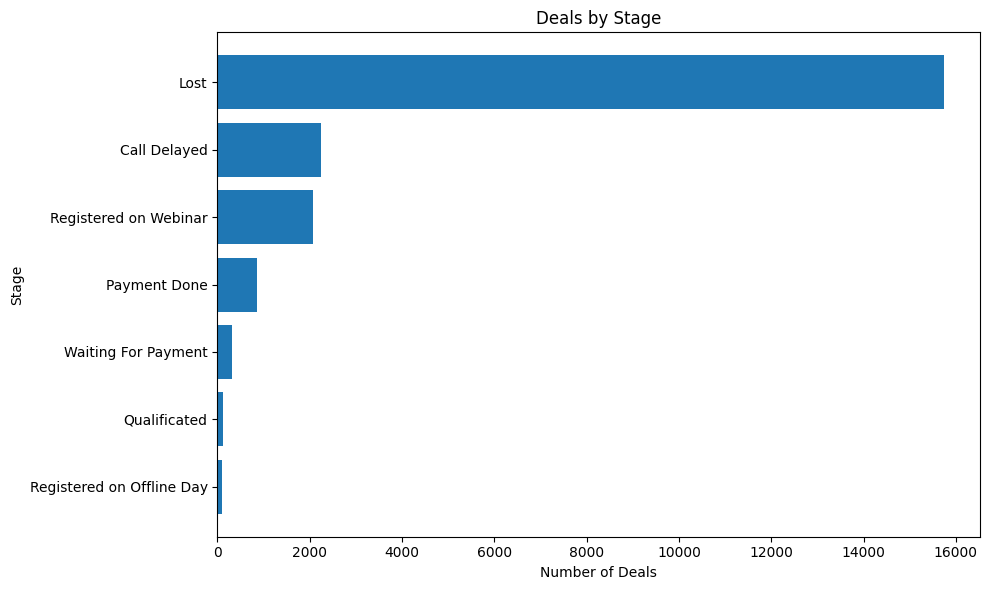

In [23]:


stage_analysis = deals_clean.groupby(
    "Stage"
).agg(
    deals=("Id", "count"),
    revenue=("amount_for_revenue", "sum")
).reset_index()

display(
    stage_analysis.sort_values(
        "deals",
        ascending=False
    )
)

plot_stage = stage_analysis[
    stage_analysis["deals"] >= 100
].sort_values("deals")

plt.figure(figsize=(10,6))

plt.barh(
    plot_stage["Stage"],
    plot_stage["deals"]
)

plt.title("Deals by Stage")
plt.xlabel("Number of Deals")
plt.ylabel("Stage")

plt.tight_layout()
plt.show()

## 17. Calls analysis

In [24]:
# calls_clean is already prepared in section 5b (cleaning). Here — analytics.
call_kpi = calls_clean.agg({"Id": "count", "Call Duration (in seconds)": ["mean", "median", "max"]})
display(call_kpi)

calls_by_owner = calls_clean.groupby("Call Owner Name").agg(
    calls=("Id", "count"),
    avg_duration_sec=("Call Duration (in seconds)", "mean")
).sort_values("calls", ascending=False).reset_index()

display(calls_by_owner.head(15))

,Id,Call Duration (in seconds)
count,"92,614.00",NaN
mean,NaN,170.34
median,NaN,9.00
max,NaN,"7,625.00"


,Call Owner Name,calls,avg_duration_sec
0,Yara Edwards,8532,99.87
1,Julia Nelson,7213,208.12
2,Ian Miller,7026,121.54
3,Charlie Davis,6943,225.16
4,Diana Evans,6713,187.26
5,Ulysses Adams,5961,205.69
6,Amy Green,5575,103.67
7,Victor Barnes,5361,146.46
8,Kevin Parker,5359,125.98
9,Nina Scott,5317,131.98


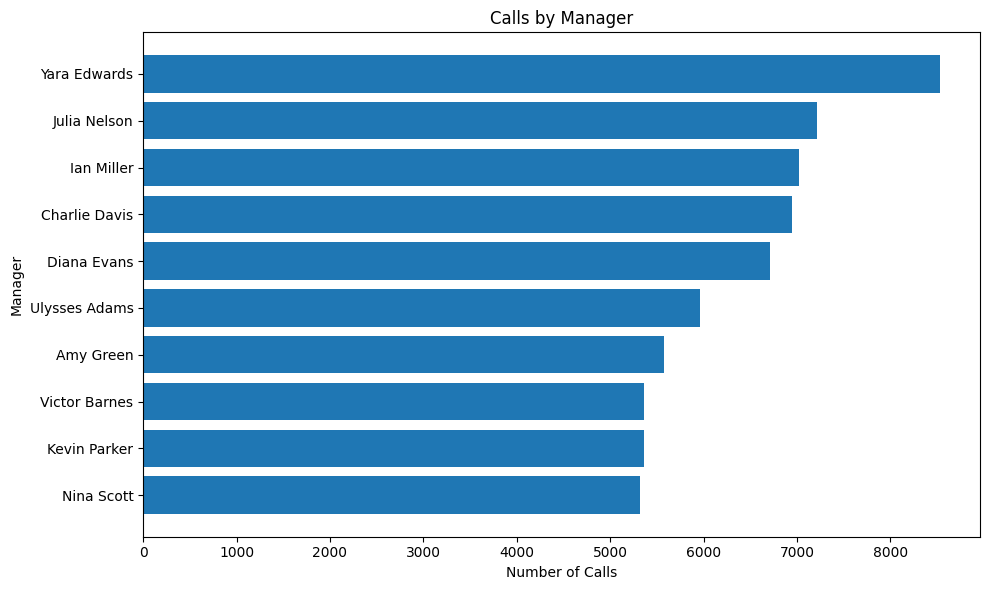

In [25]:
plt.figure(figsize=(10,6))

top_calls = (
    calls_by_owner
    .head(10)
    .sort_values("calls")
)

plt.barh(
    top_calls["Call Owner Name"],
    top_calls["calls"]
)

plt.title("Calls by Manager")
plt.xlabel("Number of Calls")
plt.ylabel("Manager")

plt.tight_layout()
plt.show()

### 17b. Relationship between deal creation and calls over time

The assignment requires not only deal dynamics but also **their relationship with calls**. We compare the monthly number of leads, successful deals and calls and compute the correlation.

Correlation (calls vs leads):            0.94
Correlation (calls vs successful deals): 0.49


,month_created,leads,success_deals,calls
0,2023-07,650,10,1923
1,2023-08,1085,49,4090
2,2023-09,1079,53,4977
3,2023-10,1598,86,6903
4,2023-11,1945,104,7008
5,2023-12,1807,105,6983
6,2024-01,2243,114,9609
7,2024-02,2183,72,9374
8,2024-03,2252,100,9556
9,2024-04,3082,76,12766


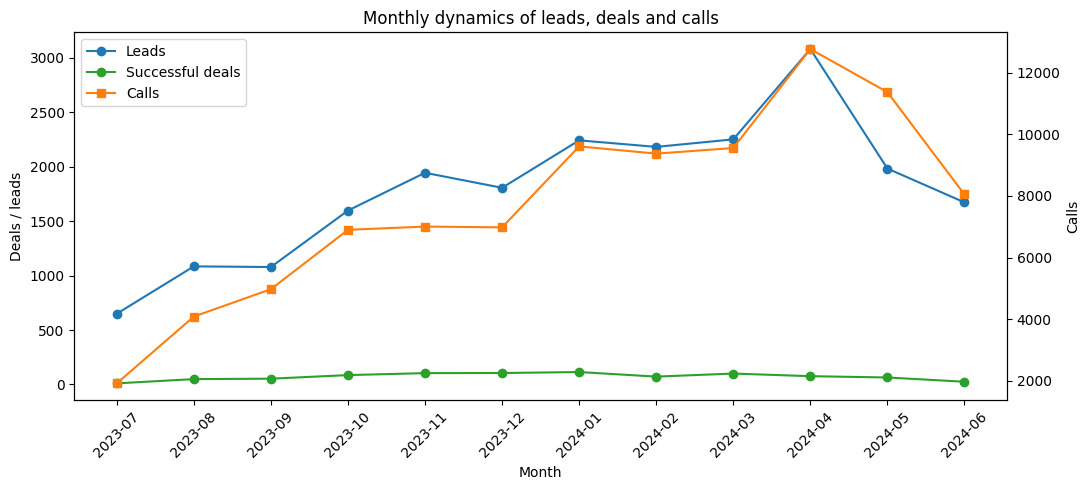

In [26]:
# Monthly call activity
calls_clean["month_call"] = calls_clean["Call Start Time"].dt.to_period("M").astype(str)
calls_monthly = (
    calls_clean.groupby("month_call")
    .agg(calls=("Id", "count"))
    .reset_index()
)

# Merge with monthly deal dynamics (monthly computed in section 13)
deals_calls = monthly.merge(
    calls_monthly, left_on="month_created", right_on="month_call", how="inner"
).sort_values("month_created")

corr_leads = deals_calls["leads"].corr(deals_calls["calls"])
corr_success = deals_calls["success_deals"].corr(deals_calls["calls"])
print(f"Correlation (calls vs leads):            {corr_leads:.2f}")
print(f"Correlation (calls vs successful deals): {corr_success:.2f}")
display(deals_calls[["month_created", "leads", "success_deals", "calls"]])

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(deals_calls["month_created"], deals_calls["leads"], marker="o", color="tab:blue", label="Leads")
ax1.plot(deals_calls["month_created"], deals_calls["success_deals"], marker="o", color="tab:green", label="Successful deals")
ax1.set_xlabel("Month")
ax1.set_ylabel("Deals / leads")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(deals_calls["month_call"], deals_calls["calls"], marker="s", color="tab:orange", label="Calls")
ax2.set_ylabel("Calls")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.title("Monthly dynamics of leads, deals and calls")
plt.tight_layout()
plt.show()

## 18. Geographic analysis

,City,leads,success_deals,revenue,cr
89,Berlin,182,78,"86,450.00",0.43
525,München,74,27,"27,100.00",0.36
291,Hamburg,62,22,"23,650.00",0.35
433,Leipzig,45,18,"16,150.00",0.40
576,Nürnberg,45,9,"12,000.00",0.20
409,Köln,25,9,"10,100.00",0.36
170,Dresden,28,9,"9,000.00",0.32
169,Dortmund,26,4,"8,500.00",0.15
224,Frankfurt,27,7,"6,800.00",0.26
178,Düsseldorf,33,7,"5,800.00",0.21


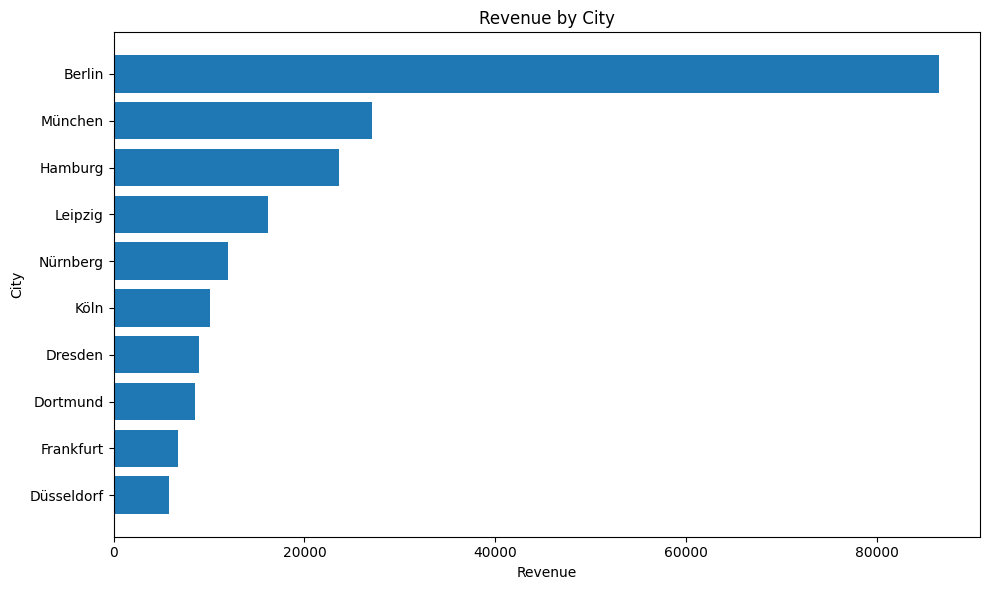

In [27]:
city_analysis = deals_clean.groupby(
    "City",
    dropna=False
).agg(
    leads=("Id", "count"),
    success_deals=("is_success", "sum"),
    revenue=("amount_for_revenue", "sum")
).reset_index()

city_analysis["cr"] = (
    city_analysis["success_deals"] /
    city_analysis["leads"]
)

city_analysis = city_analysis[
    city_analysis["City"].notna()
]

city_analysis = city_analysis[
    city_analysis["City"].astype(str).str.strip() != ""
]

city_analysis = city_analysis[
    city_analysis["City"] != "-"
]

city_analysis = city_analysis[
    city_analysis["leads"] >= 20
]

display(
    city_analysis.sort_values(
        "revenue",
        ascending=False
    ).head(15)
)

plot_city = city_analysis.sort_values(
    "revenue"
).tail(10)

plt.figure(figsize=(10,6))

plt.barh(
    plot_city["City"],
    plot_city["revenue"]
)

plt.title("Revenue by City")
plt.xlabel("Revenue")
plt.ylabel("City")

plt.tight_layout()
plt.show()

## 19. Impact of German language level

,deutsch_level,leads,success_deals,revenue,cr
45,B1,688,252,"371,600.00",0.37
93,B2,149,38,"48,000.00",0.26
13,A2,108,32,"32,000.00",0.30
91,B1/B2,31,12,"12,000.00",0.39
104,C1,25,10,"8,500.00",0.40


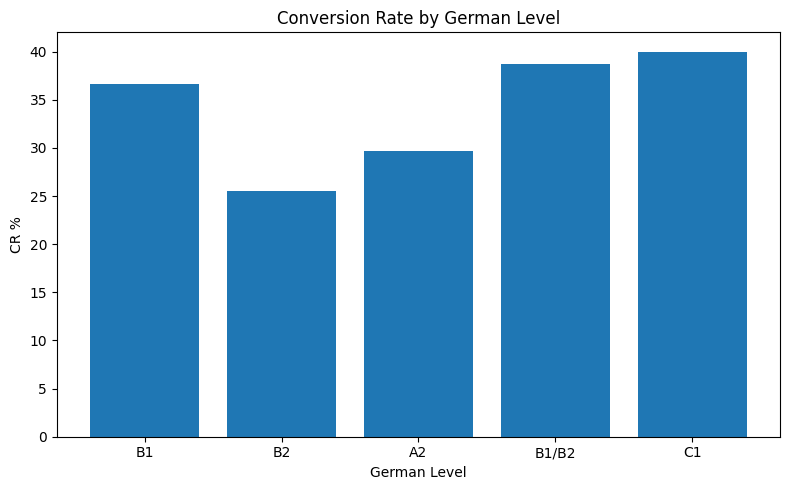

In [28]:


deutsch_clean = deals_clean.copy()


deutsch_clean["deutsch_level"] = (
    deutsch_clean["Level of Deutsch"]
    .fillna("")
    .astype(str)
    .str.upper()
    .str.strip()
)

deutsch_clean["deutsch_level"] = (
    deutsch_clean["deutsch_level"]
    .str.replace("А", "A", regex=False)
    .str.replace("В", "B", regex=False)
    .str.replace("С", "C", regex=False)
)

deutsch_clean["deutsch_level"] = deutsch_clean["deutsch_level"].replace({
    "": np.nan,
    "NAN": np.nan,
    "?": np.nan,
    "-": np.nan,

    "Б1": "B1",
    "Б2": "B2",

    "B1+": "B1",
    "B2+": "B2",
    "B1-B2": "B1/B2",

    "B1 ": "B1",
    "B2 ": "B2",
    "A1 ": "A1",
    "A2 ": "A2"
})

deutsch_analysis = (
    deutsch_clean
    .groupby("deutsch_level")
    .agg(
        leads=("Id", "count"),
        success_deals=("is_success", "sum"),
        revenue=("amount_for_revenue", "sum")
    )
    .reset_index()
)

deutsch_analysis["cr"] = (
    deutsch_analysis["success_deals"] /
    deutsch_analysis["leads"]
)

deutsch_analysis = deutsch_analysis[
    deutsch_analysis["leads"] >= 20
]

deutsch_analysis = deutsch_analysis.sort_values(
    "leads",
    ascending=False
)

display(deutsch_analysis)

plt.figure(figsize=(8,5))

plt.bar(
    deutsch_analysis["deutsch_level"],
    deutsch_analysis["cr"] * 100
)

plt.title("Conversion Rate by German Level")
plt.xlabel("German Level")
plt.ylabel("CR %")

plt.tight_layout()
plt.show()

## 20. Final conclusions

Key conclusions

1. Over the analyzed period, 21,590 leads were processed, of which 858 ended in a successful deal. Overall conversion was about 4%, and total revenue reached €943,651.

2. Traffic source effectiveness

The highest conversion among traffic sources came from:
• Webinar — 6.88%
• Organic — 5.68%
• SMM — 5.26%

The highest ROMI was shown by:
• Webinar — 1818%
• SMM — 1224%
• Facebook Ads — 558%

This indicates that these channels are the most effective in terms of the combination of conversion and marketing payback.

3. Campaign analysis

The campaigns that brought the most revenue:
• performancemax_digitalmarkt_ru_DE
• 12.07.2023wide_DE
• 02.07.2023wide_DE

These campaigns are key sales drivers and deserve further scaling.

4. Lead quality analysis

Lead quality directly affects the probability of a successful deal.

Conversion by category:
• A - High — 33%
• B - Medium — 21%
• C - Low — 10%
• D - Non Target — less than 1%
• E - Non Qualified — practically 0%

These results confirm that the lead-qualification system works correctly and show the need to focus on attracting high-quality leads.

5. Sales funnel stage analysis

The largest number of deals is in the Lost stage — more than 15 thousand records.

858 customers reached the Payment Done stage and generated all of the company's revenue. The bulk of losses occurs at the Lost stage, which makes funnel optimization one of the key directions for business growth.

A significant share of customers is also at the intermediate Call Delayed and Registered on Webinar stages, which points to potential for improving conversion through more effective work with leads at the intermediate stages.

6. Product analysis

The revenue leader is the Digital Marketing product, which brought more than €539k in revenue.

Second place is UX/UI Design with more than €261k in revenue.

7. Deal owner analysis

Among deal owners with a sufficient volume of leads, the highest conversion was shown by:
• Kevin Parker
• Ulysses Adams
• Charlie Davis

Deal owner results differ noticeably, which indicates the existence of best practices that can be scaled across the whole team.

8. Call analysis

About 95 thousand calls were processed in total.

The most active employees by number of calls are:
• Yara Edwards
• Julia Nelson
• Ian Miller

The average call duration was about 165 seconds.


9. Payment type analysis

The Payment Type field contains a large number of missing values (more than 97% of records), so payment-method results should be interpreted with caution.

Among the filled records, successful deals most often occurred for the One Payment and Recurring Payments types.

However, the available data does not allow us to claim that a specific payment method directly affects the probability of purchase. Making business decisions requires more complete population of this field in the CRM.

10. Deal closing-time analysis

Looking at all closed deals (including lost ones), the average time is ~18 days and the median is 5 days. However, this is a biased estimate: mostly lost leads "close" quickly.

For **successful** deals (Payment Done) the real sales cycle is noticeably longer: ~34 days on average, a median of ~17 days, and 75% close within ~43 days. This is the actual decision time for the customer, which is worth considering when planning deal owners' workload and the duration of A/B tests.

11. Geographic analysis

The highest revenue among cities came from:
• Berlin — €86,450
• München — €27,100
• Hamburg — €23,650

Berlin is the largest market by sales volume and number of successful deals.

12. Impact of German language level

The most common level among customers is B1.

The highest conversion was shown by:
• C1 — 40%
• B1/B2 — 39%
• B1 — 37%

At the same time, the B1 level provides the largest sales and revenue volume — more than €371k.

13. Main business growth point

The most promising growth direction is increasing the share of high-quality leads in the A-High and B-Medium categories through the most effective acquisition channels (Webinar, SMM and Facebook Ads).

This approach can increase sales conversion without a significant rise in marketing costs.

## 21. Business metrics tree

Business metrics tree

Key metric:
Revenue

Revenue depends on:

1. The number of successful deals (Successful Deals)
   └─ depends on Conversion Rate

2. The average check (Average Check)

Conversion Rate is influenced by:

- Traffic source (Source)
- Lead quality (Quality)
- Sales deal owner
- German language level
- Sales funnel stages

Average Check is influenced by:

- Product
- Payment type
- Upsells

Thus the main drivers of revenue growth are:
- improving lead quality;
- increasing conversion;
- raising the average check;
- scaling effective traffic sources.

## 22. Growth hypothesis

Growth hypothesis

Based on the analysis, several directions of business growth can be identified:

1. Reallocating part of the marketing budget toward the most effective channels (Webinar, SMM) can increase the number of successful deals without a significant rise in costs.

2. The bulk of losses occurs at the Lost stage. Optimizing deal owners' work and improving lead handling at the intermediate stages (Call Delayed and Registered on Webinar) can raise the overall funnel conversion.

3. The lead-quality analysis showed that A - High leads convert more than three times better than C - Low leads. Therefore, increasing the share of high-quality leads should positively affect the company's overall conversion.

4. The analysis revealed insufficient population of payment-method data. For a more accurate analysis of customer behavior, it is recommended to improve CRM data quality and make recording the payment method mandatory.

5. Berlin is the largest market by number of leads, successful deals and revenue. Additional marketing activities in the most successful cities can drive further sales growth.

Thus, the main growth points are improving the quality of acquired leads, optimizing the sales funnel, and scaling the most effective advertising channels.

## 22. Hypothesis testing (A/B test)

Testing the business growth hypothesis

Hypothesis:

Increasing the share of high-quality leads in the A-High and B-Medium categories,
acquired through the most effective channels Webinar and SMM,
will increase sales conversion and the company's final revenue.

Testing method:

A/B test.

Group A (control):
Current marketing strategy.

Group B (test):
Increased budget for the Webinar and SMM channels
with a focus on attracting higher-quality leads.

Primary metric:
Conversion Rate.

Secondary metrics:
- Revenue;
- Successful Deals;
- CAC;
- ROMI.

Statistical test:
two-proportion z-test, significance level α = 0.05, power 0.80.
The exact sample size is calculated below.

Test duration:
business constraint — no more than 14 days. Important: the calculation below shows that
reliably detecting a +10% uplift in full-funnel CR at a ~4% base cannot collect such a
sample in 14 days. Therefore the test is better run either on the high-quality lead
segment (A-High/B-Medium), where the base conversion is several times higher and the
effect is visible on a smaller sample, or on an earlier funnel metric
(e.g. reaching the Qualificated stage), which accumulates volume faster.

Success criterion:
a statistically significant increase in the target conversion (p-value < 0.05)
without a deterioration in CAC and ROMI.

Expected effect:
An increase in the number of successful deals
and growth of the company's overall revenue.

### Sample size estimation and statistical test

For the test to be valid, we compute the minimum sample size per group for a **two-proportion z-test** (the test comparing two conversion rates) at α = 0.05 and power 0.80.

In [29]:
from scipy import stats
import math

# Baseline conversion taken from the overall KPI (conversion_rate in %)
p1 = conversion_rate / 100          # current conversion
mde_rel = 0.10                      # target relative uplift +10%
p2 = p1 * (1 + mde_rel)             # expected conversion in the test
alpha = 0.05
power = 0.80

z_alpha = stats.norm.ppf(1 - alpha / 2)
z_power = stats.norm.ppf(power)
p_bar = (p1 + p2) / 2

n_per_group = (
    (z_alpha * math.sqrt(2 * p_bar * (1 - p_bar)) +
     z_power * math.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
) / (p2 - p1) ** 2
n_per_group = math.ceil(n_per_group)

# Average monthly lead flow -> rough duration estimate
avg_leads_per_month = monthly["leads"].mean()
days_needed = (2 * n_per_group) / (avg_leads_per_month / 30)

print(f"Baseline conversion p1:                {p1*100:.2f}%")
print(f"Target conversion p2 (+10%):         {p2*100:.2f}%")
print(f"Required sample size per group:  {n_per_group:,}")
print(f"Total leads needed (2 groups):        {2*n_per_group:,}")
print(f"Average monthly lead flow:         {avg_leads_per_month:,.0f}")
print(f"Approx. test duration:  ~{days_needed:.0f} days")

print()
print("Conclusion: at the current ~4% conversion and a relative MDE of 10%, a proper")
print("two-proportion z-test needs a sample that CANNOT be collected in 14 days.")
print("Recommendations: (1) increase the MDE / target the high-base A-High segment")
print("where the effect is more visible; or (2) extend the test; or")
print("(3) use as the primary metric not the full-funnel CR but the conversion")
print("at an earlier, more frequent funnel step.")

Baseline conversion p1:                3.98%
Target conversion p2 (+10%):         4.38%
Required sample size per group:  39,682
Total leads needed (2 groups):        79,364
Average monthly lead flow:         1,798
Approx. test duration:  ~1324 days

Conclusion: at the current ~4% conversion and a relative MDE of 10%, a proper
two-proportion z-test needs a sample that CANNOT be collected in 14 days.
Recommendations: (1) increase the MDE / target the high-base A-High segment
where the effect is more visible; or (2) extend the test; or
(3) use as the primary metric not the full-funnel CR but the conversion
at an earlier, more frequent funnel step.


## 23. Additional hypotheses testable within 14 days

A test on the **final conversion (≈4%)** is impossible within 14 days (it would need ~80k leads). To get a statistically significant result in 2 weeks, the metric must be either **frequent** (many events per day) or have a **high base** (so the required effect is caught on a smaller sample).

The data contains two such metrics:
- **Connect rate** — the status of outbound calls (`Attended` / `Unattended`). Base ~81%, ~270 calls per day — a huge volume.
- **Qualification rate** — the share of leads that reach meaningful funnel stages. Base ~16% — 4× higher than the final conversion.

First — observational support for the hypotheses on historical data, then — the calculation of the detectable effect within 14 days and the test designs.

The faster the first contact, the higher the qualification and conversion:


,leads,qualified_rate,payment_cr
sla_bucket,,,
<1h,3472,9.50,6.08
1-4h,3387,9.00,5.49
4-12h,2814,8.00,5.33
12-24h,3999,7.90,5.03



Overall connect rate: 83.1%


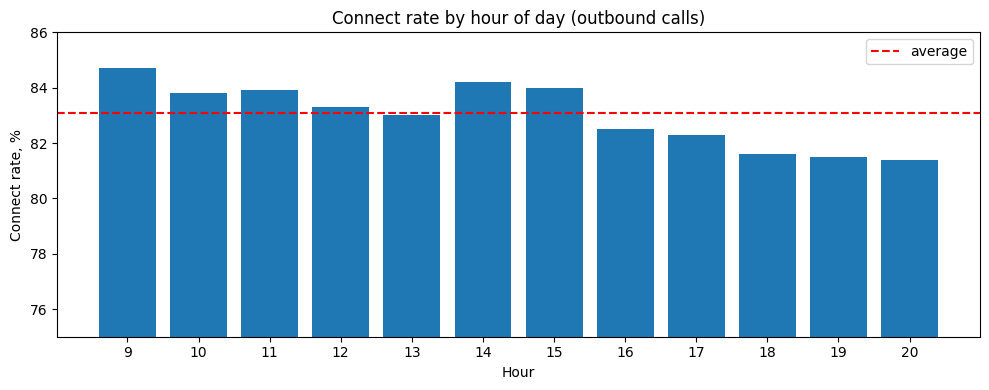

In [30]:
# --- Observation 1: time to first reaction (SLA) and the funnel ---
eng_stages = ["Qualificated", "Test Sent", "Need a consultation",
              "Registered on Webinar", "Registered on Offline Day",
              "Waiting For Payment", "Payment Done", "Free Education"]
deals_clean["is_engaged"] = deals_clean["Stage"].isin(eng_stages).astype(int)

deals_clean["sla_bucket"] = pd.cut(
    deals_clean["sla_hours"], [-0.01, 1, 4, 12, 24, 1e9],
    labels=["<1h", "1-4h", "4-12h", "12-24h", ">24h"]
)
sla_funnel = deals_clean.groupby("sla_bucket", observed=True).agg(
    leads=("Id", "count"),
    qualified_rate=("is_engaged", "mean"),
    payment_cr=("is_success", "mean")
)
sla_funnel["qualified_rate"] = (sla_funnel["qualified_rate"] * 100).round(1)
sla_funnel["payment_cr"] = (sla_funnel["payment_cr"] * 100).round(2)
print("The faster the first contact, the higher the qualification and conversion:")
display(sla_funnel)

# --- Observation 2: connect rate by hour of day ---
ob = calls_clean[
    (calls_clean["Call Type"] == "Outbound") &
    (calls_clean["Call Status"].isin(["Attended Dialled", "Unattended Dialled"]))
].copy()
ob["connected"] = (ob["Call Status"] == "Attended Dialled").astype(int)
ob["hour"] = ob["Call Start Time"].dt.hour

by_hour = ob.groupby("hour").agg(calls=("connected", "count"),
                                 connect_rate=("connected", "mean"))
by_hour = by_hour[by_hour["calls"] >= 200]
by_hour["connect_rate"] = (by_hour["connect_rate"] * 100).round(1)

base_connect = ob["connected"].mean()
print(f"\nOverall connect rate: {base_connect*100:.1f}%")

plt.figure(figsize=(10, 4))
plt.bar(by_hour.index.astype(str), by_hour["connect_rate"])
plt.axhline(base_connect * 100, color="red", linestyle="--", label="average")
plt.title("Connect rate by hour of day (outbound calls)")
plt.xlabel("Hour"); plt.ylabel("Connect rate, %")
plt.ylim(75, 86); plt.legend(); plt.tight_layout(); plt.show()

In [31]:
from scipy import stats
import math

def required_n(p1, mde_abs, alpha=0.05, power=0.8):
    """Sample size per group for a two-proportion z-test."""
    p2 = p1 + mde_abs
    za, zb = stats.norm.ppf(1 - alpha/2), stats.norm.ppf(power)
    pbar = (p1 + p2) / 2
    return math.ceil(((za*math.sqrt(2*pbar*(1-pbar)) +
                       zb*math.sqrt(p1*(1-p1)+p2*(1-p2)))**2) / (p2-p1)**2)

def detectable_mde(p1, n, alpha=0.05, power=0.8):
    """Minimum detectable effect (absolute) for a given sample size per group."""
    d = 0.0005
    while d < 0.5:
        if required_n(p1, d, alpha, power) <= n:
            return d
        d += 0.0005
    return None

# Daily volumes from historical data
span_days = (deals_clean["created_date"].max() - deals_clean["created_date"].min()).days
leads_day = len(deals_clean) / span_days
outbound_day = len(ob) / span_days

rows = []
for name, p1, daily in [
    ("Connect rate",     base_connect, outbound_day),
    ("Qualification rate", deals_clean["is_engaged"].mean(), leads_day),
    ("Payment CR",       deals_clean["is_success"].mean(), leads_day),
]:
    n_group = daily * 14 / 2          # 50/50 split over 14 days
    mde = detectable_mde(p1, n_group)
    rows.append({
        "metric": name,
        "base": f"{p1*100:.1f}%",
        "n_per_group_14d": int(n_group),
        "MDE_abs": f"+{mde*100:.1f} pp" if mde else ">observed",
        "MDE_rel": f"+{mde/p1*100:.0f}%" if mde else "-",
        "feasible_14d": "YES" if mde and mde/p1 <= 0.30 else "large effect only",
    })
feasibility = pd.DataFrame(rows)
print("What can realistically be detected within 14 days (alpha=0.05, power=0.80):")
display(feasibility)

What can realistically be detected within 14 days (alpha=0.05, power=0.80):


,metric,base,n_per_group_14d,MDE_abs,MDE_rel,feasible_14d
0,Connect rate,83.1%,1659,+3.5 pp,+4%,YES
1,Qualification rate,16.3%,427,+7.7 pp,+47%,large effect only
2,Payment CR,4.0%,427,+4.7 pp,+118%,large effect only


### Test designs (fit within 14 days)

**Hypothesis 1 — optimizing call timing → higher connect rate (primary candidate).**
Observation: in the 9:00–16:00 window the connect rate is 82–84%, in the evening (17:00–20:00) it is 79–80%. Shifting part of the outbound attempts into the "reachable" windows should raise the connect rate.
- Metric: connect rate = Attended / (Attended + Unattended), at the call level.
- Base ~81.5%, ~1,700 calls per group over 14 days → we can detect **+3.6 pp**. The observed spread across hours (~4 pp) is within the sensitivity range.
- Design: random A/B split of leads/deal owners; group B is called mostly within the high-reachability windows. Success criterion: a significant (p<0.05) increase in connect rate without a drop in average call duration.

**Hypothesis 2 — instant re-dial on a missed call → higher connect rate.**
Same volumes and metric as in H1, so the test is just as powerful within 14 days. Idea: on an `Unattended` status, auto-redial after 5–10 minutes.

**Hypothesis 3 — speed of first contact (speed-to-lead) → qualification (directional).**
Observation: leads contacted within an hour are qualified at 9.5% vs 7.9% with a 12–24h delay. The metric is the quality/qualification rate (base 16%). Within 14 days only an effect of **≥ +7.7 pp (rel. +47%)** is detectable, which is larger than the historical gap. The honest conclusion: on qualification, a 14-day test is **underpowered**; it should either be extended or measured on the connect rate (as in H1/H2), where there is enough power. This illustrates why the right choice of metric matters more than the hypothesis itself.

In [32]:
# --- Function to evaluate an A/B test result (two-proportion z-test) ---
def ab_test_proportions(success_a, n_a, success_b, n_b, alpha=0.05):
    p_a, p_b = success_a/n_a, success_b/n_b
    p_pool = (success_a + success_b) / (n_a + n_b)
    se = math.sqrt(p_pool*(1-p_pool)*(1/n_a + 1/n_b))
    z = (p_b - p_a) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return {
        "CR_A": round(p_a*100, 2), "CR_B": round(p_b*100, 2),
        "uplift_pp": round((p_b-p_a)*100, 2),
        "uplift_rel_%": round((p_b/p_a - 1)*100, 1),
        "z": round(z, 2), "p_value": round(p_value, 4),
        "significant": p_value < alpha
    }

# Example: H1 over 14 days. Control 81.5% connect rate, test +3.6 pp.
n = 1720
res = ab_test_proportions(int(0.815*n), n, int(0.851*n), n)
print("Example evaluation of the H1 test result (connect rate):")
for k, v in res.items():
    print(f"  {k}: {v}")

Example evaluation of the H1 test result (connect rate):
  CR_A: 81.45
  CR_B: 85.06
  uplift_pp: 3.6
  uplift_rel_%: 4.4
  z: 2.83
  p_value: 0.0046
  significant: True


## 22. Conclusion

During the project, the main drivers of business growth were identified. The greatest impact on sales comes from lead quality, traffic sources and deal owner effectiveness.

The most promising growth direction is increasing the share of high-quality leads in the A-High and B-Medium categories through the most effective acquisition channels, followed by validating the hypothesis via A/B testing.